# EuroSAT baseline classifier

Pipeline sanity-check: train/val split, data loading, training loop, metrics.

Note: EuroSAT gives one label per whole image (classification), not pixel masks. This is *not* the final segmentation model — it just proves the training pipeline works before moving to real Sentinel-2 + ESA WorldCover segmentation data.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import torch
from torch import nn

from helpers.dataloaders import load_eurosat_data, build_dataloaders
from models.resnet18_classifier_builder import build_resnet18_classifier
from training.engine import Engine
from training.evaluate import evaluate_classifier, draw_confusion_matrix


DATA_DIR = Path.cwd().parent / "data"

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


### 1/ Load EuroSat data (preprocessed with a transform)


In [2]:

full_dataset = load_eurosat_data()

classes = full_dataset.classes

print(f"{len(full_dataset)} images, {len(classes)} classes: {classes}")

27000 images, 10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


###  2/ Split the dataset into training, validation and test DataLoader


In [3]:

BATCH_SIZE = 64
SEED_NUM = 42
train_loader, val_loader, test_loader = build_dataloaders(full_dataset, BATCH_SIZE, 0.7, 0.15, SEED_NUM)


###  3/ Load the pretrained ResNet18 model and modify the final fully connected layer to match the number of classes in EuroSAT
#### TODO : maybe use a different model, like EfficientNet, or a custom CNN, or a ViT (Vision Transformer) model


In [4]:
# 3/ Load the pretrained ResNet18 model and modify the final fully connected layer to match the number of classes in EuroSAT
# TODO : maybe use a different model, like EfficientNet, or a custom CNN, or a ViT (Vision Transformer) model

model = build_resnet18_classifier(num_classes=len(classes), device=device)

# 7/ Define the loss function
# CrossEntropyLoss combine en une seule opération LogSoftmax + NLLLoss (Negative Log-Likelihood Loss)
# -> parfait pour classification multi-classe, mono-label (1 image = 1 classe)
#
# Alternatives :
# - nn.NLLLoss                          -> meme chose mais il faut appliquer soi-meme LogSoftmax avant
# - nn.BCEWithLogitsLoss                -> si multi-label (une image pourrait avoir plusieurs classes en meme temps)
# - CrossEntropyLoss(weight=...)        -> si les classes etaient desequilibrees (pondere chaque classe)
# - CrossEntropyLoss(label_smoothing=.1)-> reduit la sur-confiance du modele, ameliore la generalisation
# - Focal Loss (pas native PyTorch)     -> utile si classes rares/difficiles (frequent en teledetection)
# - Dice Loss / Dice+CE                 -> pour la future segmentation d'images (ex: segmenter les routes, les batiments, etc.)
loss_fn = nn.CrossEntropyLoss()

# NB : l'optimiseur n'est plus défini ici, chaque phase (freeze-first) a le sien -> voir cellule d'entraînement

### 4/ Train the model


In [7]:
# Run the model train - freeze-first transfer learning (2 phases)

from models.resnet18_classifier_builder import freeze_backbone, unfreeze_backbone

EPOCHS_PHASE1 = 6  # backbone gelé, seule la tête s'entraîne
EPOCHS_PHASE2 = 9  # backbone dégelé, tout le réseau s'affine à un lr plus faible

# Phase 1 : backbone gelé, seule la tête (fc) s'entraîne
# lr plus élevé car la tête est initialisée aléatoirement et doit apprendre vite
freeze_backbone(model)
optimizer_phase1 = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
engine_phase1 = Engine(device, loss_fn, optimizer_phase1)
engine_phase1.display_info()
history_phase1 = engine_phase1.train_model(model, train_loader, val_loader, EPOCHS_PHASE1)

# Phase 2 : backbone dégelé, tout le réseau s'affine à un lr plus faible
# lr faible pour ne pas détruire les features pré-entraînées pendant le fine-tuning
unfreeze_backbone(model)
optimizer_phase2 = torch.optim.Adam(model.parameters(), lr=1e-5)
engine_phase2 = Engine(device, loss_fn, optimizer_phase2)
engine_phase2.display_info()
history_phase2 = engine_phase2.train_model(model, train_loader, val_loader, EPOCHS_PHASE2)

# Fusion des historiques des deux phases pour le plot ci-dessous
history = {key: history_phase1[key] + history_phase2[key] for key in history_phase1}

device: mps, loss_fn: CrossEntropyLoss(), optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Epoch 1/6 - Train Loss: 0.9010, Train Acc: 0.7319 - Val Loss: 0.5607, Val Acc: 0.8343
Epoch 2/6 - Train Loss: 0.5322, Train Acc: 0.8338 - Val Loss: 0.4890, Val Acc: 0.8499
Epoch 3/6 - Train Loss: 0.4835, Train Acc: 0.8446 - Val Loss: 0.4562, Val Acc: 0.8568
Epoch 4/6 - Train Loss: 0.4538, Train Acc: 0.8543 - Val Loss: 0.4530, Val Acc: 0.8598
Epoch 5/6 - Train Loss: 0.4492, Train Acc: 0.8537 - Val Loss: 0.4540, Val Acc: 0.8553
Epoch 6/6 - Train Loss: 0.4256, Train Acc: 0.8599 - Val Loss: 0.4548, Val Acc: 0.8583
device: mps, loss_fn: CrossEntropyLoss(), optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False

#### Comparaison : baseline single-phase (sans freeze), même nombre total d'epochs

In [8]:
# Baseline (comparaison) : fine-tuning single-phase, tout le réseau entraîné dès le départ, sans freeze
# Nouveau modèle indépendant (mêmes poids ImageNet de départ) pour ne pas repartir des poids déjà affinés par le freeze-first

model_baseline = build_resnet18_classifier(num_classes=len(classes), device=device)

EPOCHS_BASELINE = EPOCHS_PHASE1 + EPOCHS_PHASE2  # même nombre total d'epochs que le freeze-first, pour comparer à effort égal

optimizer_baseline = torch.optim.Adam(model_baseline.parameters(), lr=1e-4)
engine_baseline = Engine(device, loss_fn, optimizer_baseline)
engine_baseline.display_info()

history_baseline = engine_baseline.train_model(model_baseline, train_loader, val_loader, EPOCHS_BASELINE)

device: mps, loss_fn: CrossEntropyLoss(), optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Epoch 1/15 - Train Loss: 0.3223, Train Acc: 0.8972 - Val Loss: 0.1201, Val Acc: 0.9635
Epoch 2/15 - Train Loss: 0.0724, Train Acc: 0.9764 - Val Loss: 0.1096, Val Acc: 0.9640
Epoch 3/15 - Train Loss: 0.0482, Train Acc: 0.9848 - Val Loss: 0.1194, Val Acc: 0.9632
Epoch 4/15 - Train Loss: 0.0332, Train Acc: 0.9897 - Val Loss: 0.1189, Val Acc: 0.9640
Epoch 5/15 - Train Loss: 0.0300, Train Acc: 0.9905 - Val Loss: 0.1353, Val Acc: 0.9580
Epoch 6/15 - Train Loss: 0.0295, Train Acc: 0.9900 - Val Loss: 0.1202, Val Acc: 0.9674
Epoch 7/15 - Train Loss: 0.0229, Train Acc: 0.9928 - Val Loss: 0.1258, Val Acc: 0.9677
Epoch 8/15 - Train Loss: 0.0249, Train Acc: 0.9916 - Val Loss: 0.1337, Val Acc: 0.

#### Comparaison : autre famille de modèle (EfficientNet-B0), même stratégie freeze-first (2 phases) que le run ResNet18

In [ ]:
# Comparaison modèle : EfficientNet-B0 (autre famille CNN, meilleur ratio précision/paramètres que ResNet18)
# Même stratégie freeze-first (2 phases) que le run ResNet18 pour isoler l'effet du choix d'architecture

from models.efficientnet_b0_classifier_builder import build_efficientnet_b0_classifier, freeze_backbone, unfreeze_backbone

model_efficientnet = build_efficientnet_b0_classifier(num_classes=len(classes), device=device)

# Phase 1 : backbone gelé, seule la tête (classifier) s'entraîne
print("Phase 1 : backbone gelé, seule la tête (classifier) s'entraîne")
freeze_backbone(model_efficientnet)
optimizer_efficientnet_phase1 = torch.optim.Adam(model_efficientnet.classifier.parameters(), lr=1e-3)
engine_efficientnet_phase1 = Engine(device, loss_fn, optimizer_efficientnet_phase1)
#engine_efficientnet_phase1.display_info()
history_efficientnet_phase1 = engine_efficientnet_phase1.train_model(model_efficientnet, train_loader, val_loader, EPOCHS_PHASE1)

# Phase 2 : backbone dégelé, tout le réseau s'affine à un lr plus faible
print("Phase 2 : backbone dégelé, tout le réseau s'affine à un lr plus faible")
unfreeze_backbone(model_efficientnet)
optimizer_efficientnet_phase2 = torch.optim.Adam(model_efficientnet.parameters(), lr=1e-5)
engine_efficientnet_phase2 = Engine(device, loss_fn, optimizer_efficientnet_phase2)
#engine_efficientnet_phase2.display_info()
history_efficientnet_phase2 = engine_efficientnet_phase2.train_model(model_efficientnet, train_loader, val_loader, EPOCHS_PHASE2)

# Fusion des historiques des deux phases pour le plot
history_efficientnet = {key: history_efficientnet_phase1[key] + history_efficientnet_phase2[key] for key in history_efficientnet_phase1}

device: mps, loss_fn: CrossEntropyLoss(), optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Epoch 1/6 - Train Loss: 0.8996, Train Acc: 0.7254 - Val Loss: 0.6172, Val Acc: 0.8111
Epoch 2/6 - Train Loss: 0.6383, Train Acc: 0.7925 - Val Loss: 0.5635, Val Acc: 0.8185
Epoch 3/6 - Train Loss: 0.5994, Train Acc: 0.8022 - Val Loss: 0.5519, Val Acc: 0.8220
Epoch 4/6 - Train Loss: 0.5858, Train Acc: 0.8052 - Val Loss: 0.5387, Val Acc: 0.8254
Epoch 5/6 - Train Loss: 0.5804, Train Acc: 0.8055 - Val Loss: 0.5207, Val Acc: 0.8284
Epoch 6/6 - Train Loss: 0.5876, Train Acc: 0.8047 - Val Loss: 0.5113, Val Acc: 0.8247
device: mps, loss_fn: CrossEntropyLoss(), optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False

#### Comparaison : autre loss function (label smoothing), même modèle/stratégie que le baseline

In [10]:
# Comparaison loss : CrossEntropyLoss avec label smoothing (réduit la sur-confiance, régularise)
# Même modèle (ResNet18) et même stratégie (single-phase) que le baseline pour isoler l'effet de la loss

model_label_smoothing = build_resnet18_classifier(num_classes=len(classes), device=device)
loss_fn_label_smoothing = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_label_smoothing = torch.optim.Adam(model_label_smoothing.parameters(), lr=1e-4)
engine_label_smoothing = Engine(device, loss_fn_label_smoothing, optimizer_label_smoothing)
engine_label_smoothing.display_info()

history_label_smoothing = engine_label_smoothing.train_model(model_label_smoothing, train_loader, val_loader, EPOCHS_BASELINE)

device: mps, loss_fn: CrossEntropyLoss(), optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Epoch 1/15 - Train Loss: 0.7712, Train Acc: 0.9013 - Val Loss: 0.6119, Val Acc: 0.9640
Epoch 2/15 - Train Loss: 0.5849, Train Acc: 0.9741 - Val Loss: 0.5889, Val Acc: 0.9669
Epoch 3/15 - Train Loss: 0.5451, Train Acc: 0.9900 - Val Loss: 0.5799, Val Acc: 0.9719
Epoch 4/15 - Train Loss: 0.5287, Train Acc: 0.9952 - Val Loss: 0.5691, Val Acc: 0.9746
Epoch 5/15 - Train Loss: 0.5233, Train Acc: 0.9961 - Val Loss: 0.5710, Val Acc: 0.9723
Epoch 6/15 - Train Loss: 0.5193, Train Acc: 0.9966 - Val Loss: 0.5773, Val Acc: 0.9709
Epoch 7/15 - Train Loss: 0.5208, Train Acc: 0.9954 - Val Loss: 0.5679, Val Acc: 0.9716
Epoch 8/15 - Train Loss: 0.5166, Train Acc: 0.9967 - Val Loss: 0.5822, Val Acc: 0.

#### Show loss function and accuracy curves

In [ ]:
# 10/ Plot the training and validation loss and accuracy curves — comparaison des 4 approches
# (val uniquement pour la lisibilité : train curves disponibles dans history_*["train_loss"/"train_acc"])
import matplotlib.pyplot as plt

runs = {
    "freeze-first (ResNet18)": history,
    "baseline (ResNet18)": history_baseline,
    "EfficientNet-B0": history_efficientnet,
    "label smoothing (ResNet18)": history_label_smoothing,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, h in runs.items():
    axes[0].plot(h["val_loss"], label=label)
    axes[1].plot(h["val_acc"], label=label)

axes[0].set_title("Validation Loss")
axes[0].legend()

axes[1].set_title("Validation Accuracy")
axes[1].legend()
plt.show()

## Test set evaluation

#### Evaluation of the trained model on the "test" split set [backbone freezed + unfreezed]



                      precision    recall  f1-score   support

          AnnualCrop       0.94      0.94      0.94       472
              Forest       0.98      0.98      0.98       442
HerbaceousVegetation       0.92      0.93      0.93       458
             Highway       0.93      0.87      0.90       391
          Industrial       0.98      0.96      0.97       378
             Pasture       0.92      0.94      0.93       299
       PermanentCrop       0.92      0.89      0.90       379
         Residential       0.97      0.98      0.98       450
               River       0.90      0.94      0.92       375
             SeaLake       0.98      0.99      0.98       406

            accuracy                           0.94      4050
           macro avg       0.94      0.94      0.94      4050
        weighted avg       0.94      0.94      0.94      4050



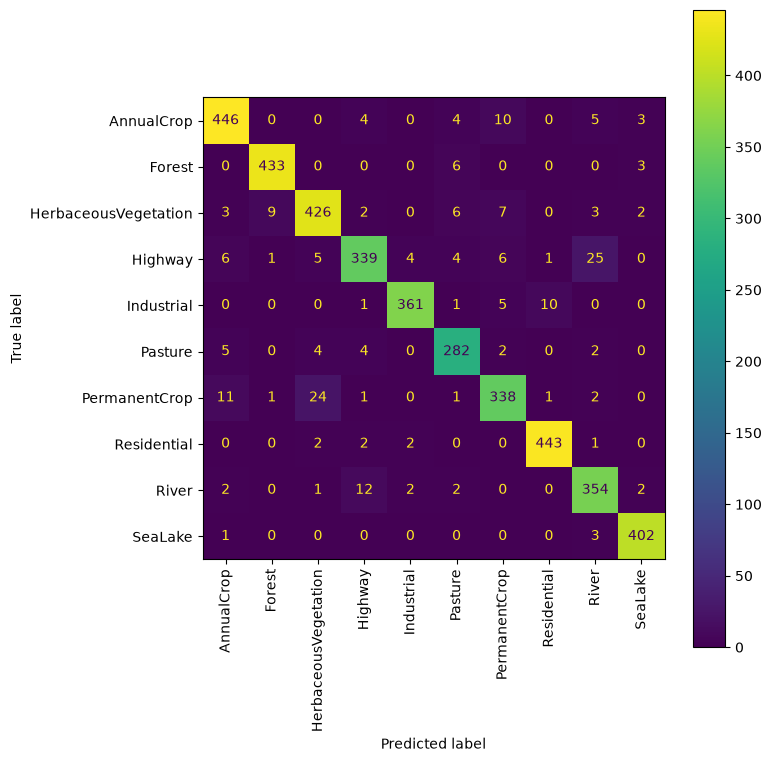

In [14]:

all_preds, all_labels = evaluate_classifier(model, test_loader, device, classes, verbose=True)

draw_confusion_matrix(all_labels, all_preds, classes)


#### Evaluation of the trained model on the "test" split set [all network fine tuned]




                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.96      0.96       472
              Forest       0.99      0.98      0.98       442
HerbaceousVegetation       0.98      0.95      0.97       458
             Highway       0.93      0.98      0.96       391
          Industrial       0.99      0.96      0.98       378
             Pasture       0.95      0.95      0.95       299
       PermanentCrop       0.93      0.94      0.94       379
         Residential       0.99      0.98      0.99       450
               River       0.95      0.96      0.96       375
             SeaLake       0.98      0.99      0.98       406

            accuracy                           0.97      4050
           macro avg       0.96      0.97      0.96      4050
        weighted avg       0.97      0.97      0.97      4050



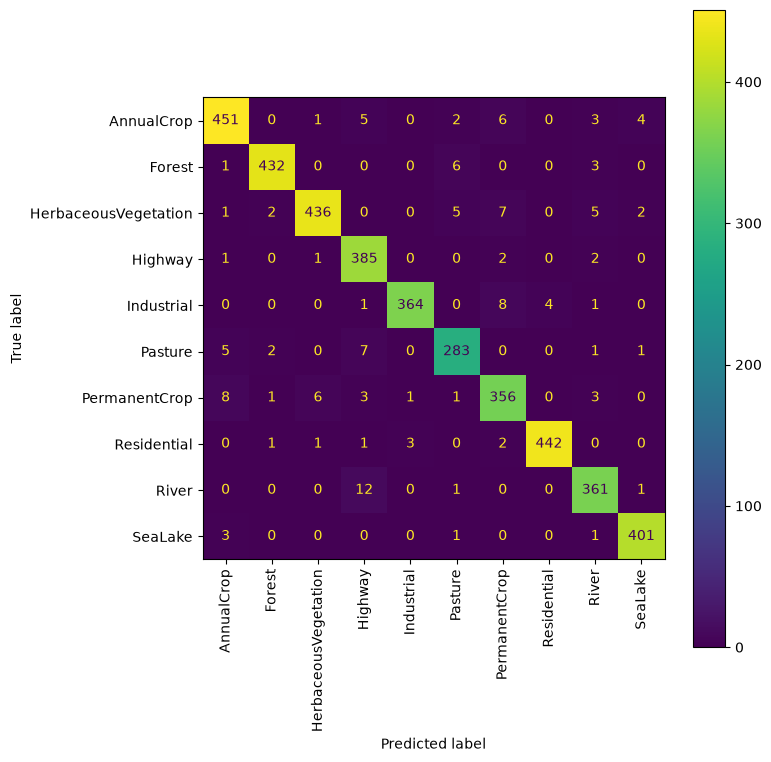

In [15]:
all_preds_baseline, all_labels_baseline = evaluate_classifier(model_baseline, test_loader, device, classes, verbose=True)

draw_confusion_matrix(all_labels_baseline, all_preds_baseline, classes)


### Save the trained weight in a binary to reuse it

In [8]:
CHECKPOINT_DIR = Path.cwd().parent / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
# model.state_dict() -> retourne un dictionnaire Python contenant tous les poids appris du réseau (les tenseurs de model.fc, des couches convolutives ResNet18, etc.), sans l'architecture elle-même.
torch.save(model.state_dict(), CHECKPOINT_DIR / "resnet18_eurosat.pth")
print(f"Saved checkpoint to {CHECKPOINT_DIR / 'resnet18_eurosat.pth'}")

Saved checkpoint to /Users/erizzolio/Work/Alyra/SOLSCAN/checkpoints/resnet18_eurosat.pth
